# Zomato User Behavior — Unsupervised Segmentation Project

**Dataset:** `zomato_user_data_-_LMS.csv` (3,640 users, 22 columns)

**Goal:** No labels are available — we use **unsupervised learning** (PCA + K-Means) to discover natural
behavioral segments among Zomato users, based on their engagement, ordering, spending and experience signals.

This notebook works through:
- **Q1** Exploratory Data Analysis
- **Q2** Data Preparation & Exploration (data quality, outliers, correlation)
- **Q3** Dimensionality Reduction using PCA
- **Q4** Clustering (K-Means) and Interpretation


## 0. Setup & Data Loading

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

df = pd.read_csv(r"C:\Users\samriddhiashoksingh\OneDrive\Desktop\PGA38\Machine Learning\ML Exam\file\zomato_users.csv")
print('Shape:', df.shape)
df.head()


Shape: (3640, 22)


,user_id,city,device_type,subscription_status,user_segment_label,preferred_cuisine,app_opens_per_month,avg_session_duration_minutes,browse_sessions_without_order,orders_per_month,...,discount_usage_rate,promo_orders_ratio,weekend_order_ratio,late_night_orders_ratio,peak_hour_orders_ratio,days_since_last_order,avg_delivery_time_minutes,order_cancellation_rate,app_rating_given,customer_support_chats
0,ZOM200000,Hyderabad,iOS,NaN,Returning,North Indian,26.740168,8.965961,8.465340,4.815482,...,0.355390,0.629073,0.326298,0.451233,0.525325,8.390026,32.193597,0.019575,4.362833,0
1,ZOM200001,Kolkata,iOS,NaN,Returning,Chinese,10.145544,6.343538,10.526948,0.276121,...,0.227851,0.005544,0.643287,0.000000,0.434892,26.205100,26.341917,0.068982,4.295368,2
2,ZOM200002,Kolkata,Android,Zomato Gold,Returning,Italian,23.190429,7.971666,12.844486,3.517156,...,0.523863,0.338718,0.446290,0.250970,0.606698,13.669060,28.575752,0.049404,4.543003,0
3,ZOM200003,Hyderabad,Android,Zomato Gold,Returning,South Indian,13.083080,6.911308,9.543095,2.315705,...,0.342982,0.717055,0.215513,0.401037,0.628076,20.310362,21.667125,0.040058,4.286456,0
4,ZOM200004,Bangalore,Android,NaN,Long-Term,Desserts,61.488038,16.936118,5.490302,19.726369,...,0.279026,0.199145,0.292876,0.374529,0.398572,3.435409,40.145218,0.104421,3.827626,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3640 entries, 0 to 3639
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        3640 non-null   object 
 1   city                           3640 non-null   object 
 2   device_type                    3640 non-null   object 
 3   subscription_status            1205 non-null   object 
 4   user_segment_label             3640 non-null   object 
 5   preferred_cuisine              3512 non-null   object 
 6   app_opens_per_month            3640 non-null   float64
 7   avg_session_duration_minutes   3640 non-null   float64
 8   browse_sessions_without_order  3640 non-null   float64
 9   orders_per_month               3640 non-null   float64
 10  avg_order_value                3515 non-null   float64
 11  monthly_food_spend             3640 non-null   float64
 12  discount_usage_rate            3523 non-null   f

## Q1. Exploratory Data Analysis

### 1.1 Distribution of key numerical engagement / ordering features

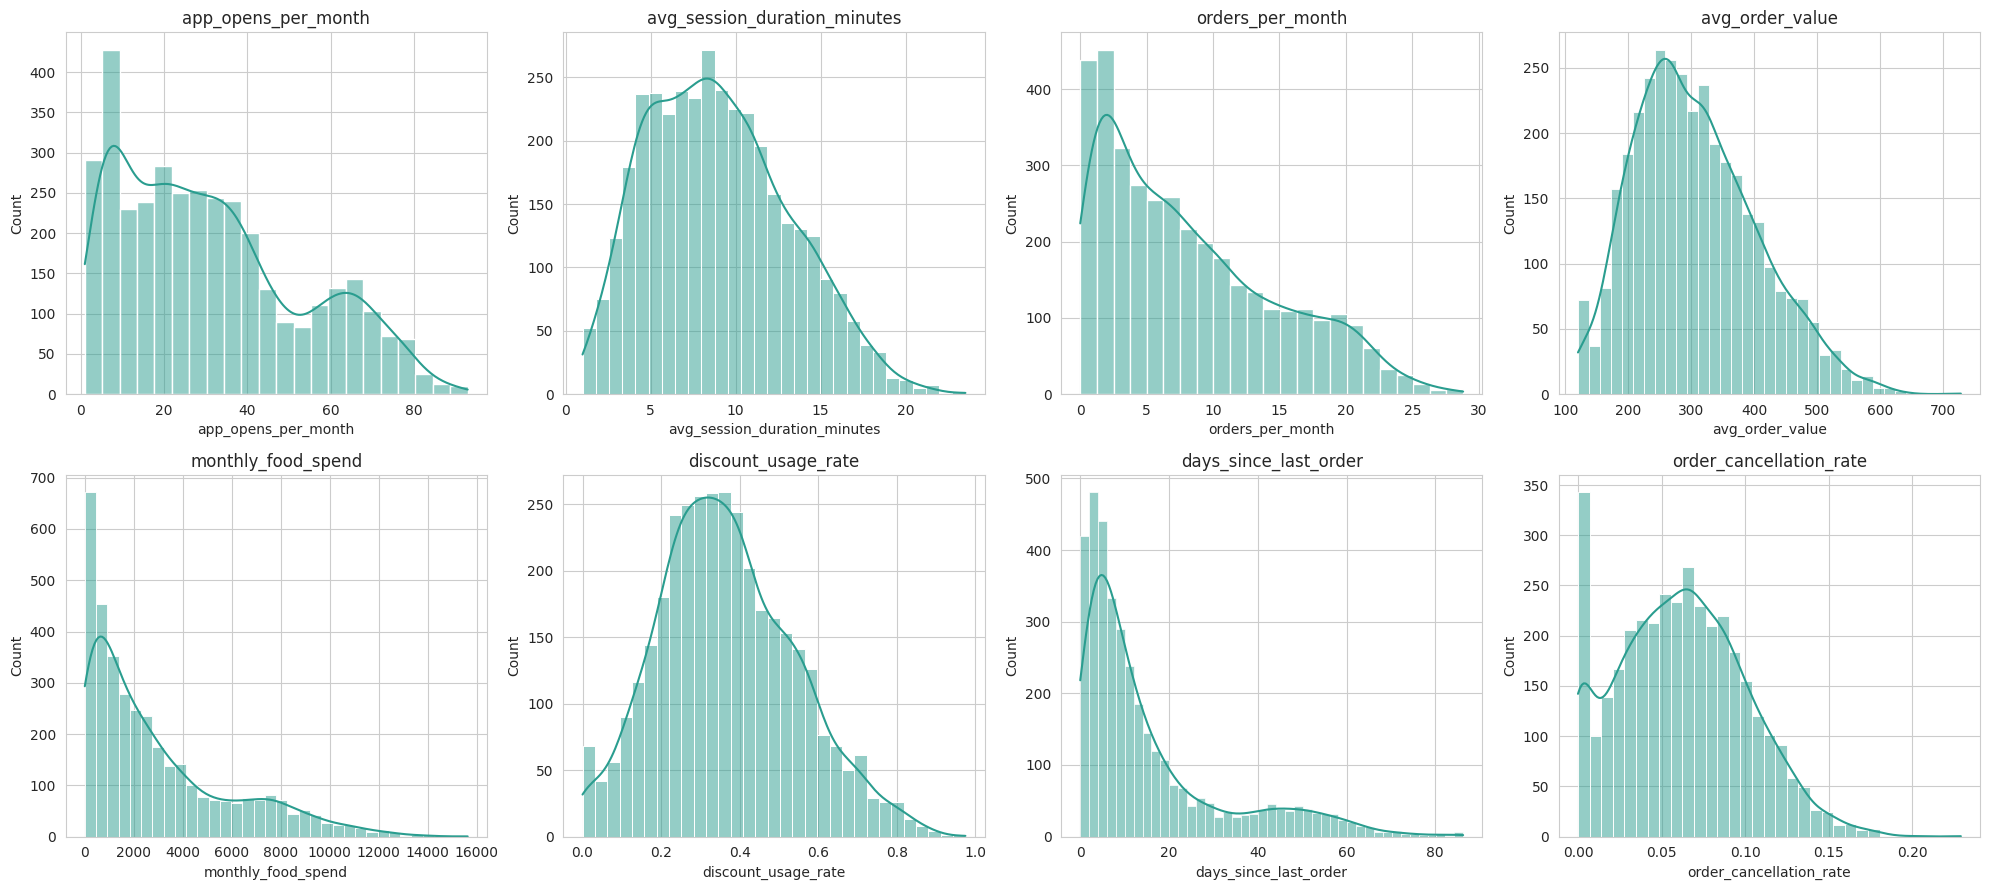

In [3]:
key_numeric = ['app_opens_per_month', 'avg_session_duration_minutes', 'orders_per_month',
               'avg_order_value', 'monthly_food_spend', 'discount_usage_rate',
               'days_since_last_order', 'order_cancellation_rate']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(key_numeric):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='#2a9d8f')
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('figs/q1_numeric_distributions.png', dpi=110)
plt.show()


In [4]:
df[key_numeric].describe().T


,count,mean,std,min,25%,50%,75%,max
app_opens_per_month,3640.0,31.417018,21.867587,1.0,12.805050,27.652682,45.185416,92.860499
avg_session_duration_minutes,3640.0,8.978461,4.150225,1.0,5.678100,8.592448,11.767167,23.501570
orders_per_month,3640.0,8.172064,6.536859,0.0,2.573166,6.648735,12.432898,28.826003
avg_order_value,3515.0,306.522115,97.296212,120.0,234.144273,294.029918,368.783112,728.530414
monthly_food_spend,3640.0,2955.965880,2938.193523,0.0,685.957684,1923.754815,4321.268097,15637.170170
discount_usage_rate,3523.0,0.367788,0.174987,0.0,0.245063,0.353524,0.484411,0.974509
days_since_last_order,3640.0,15.501725,16.775695,0.0,4.062031,9.045135,19.565383,86.272746
order_cancellation_rate,3640.0,0.062079,0.038277,0.0,0.033383,0.061463,0.088159,0.229085


**Observations on numeric distributions:**

- **`app_opens_per_month`, `orders_per_month`, `monthly_food_spend`** are all **right-skewed** — most users open
  the app / order moderately, but a smaller set of highly-engaged "power users" open the app very frequently and
  spend a lot, pulling the tail to the right.
- **`avg_order_value`** is roughly bell-shaped, clustering in a moderate range, with a thinner tail of
  higher-ticket orders.
- **`discount_usage_rate`** spans the full 0–1 range fairly broadly, suggesting a real mix of discount-driven vs
  full-price customers rather than one dominant behavior.
- **`days_since_last_order`** is strongly right-skewed — most users ordered fairly recently, but a minority have
  gone a long time without ordering (early churn-risk signal).
- **`order_cancellation_rate`** is low for the large majority of users with a long right tail — a small group of
  users cancels noticeably more often than typical.


### 1.2 Categorical feature analysis (at least three features)

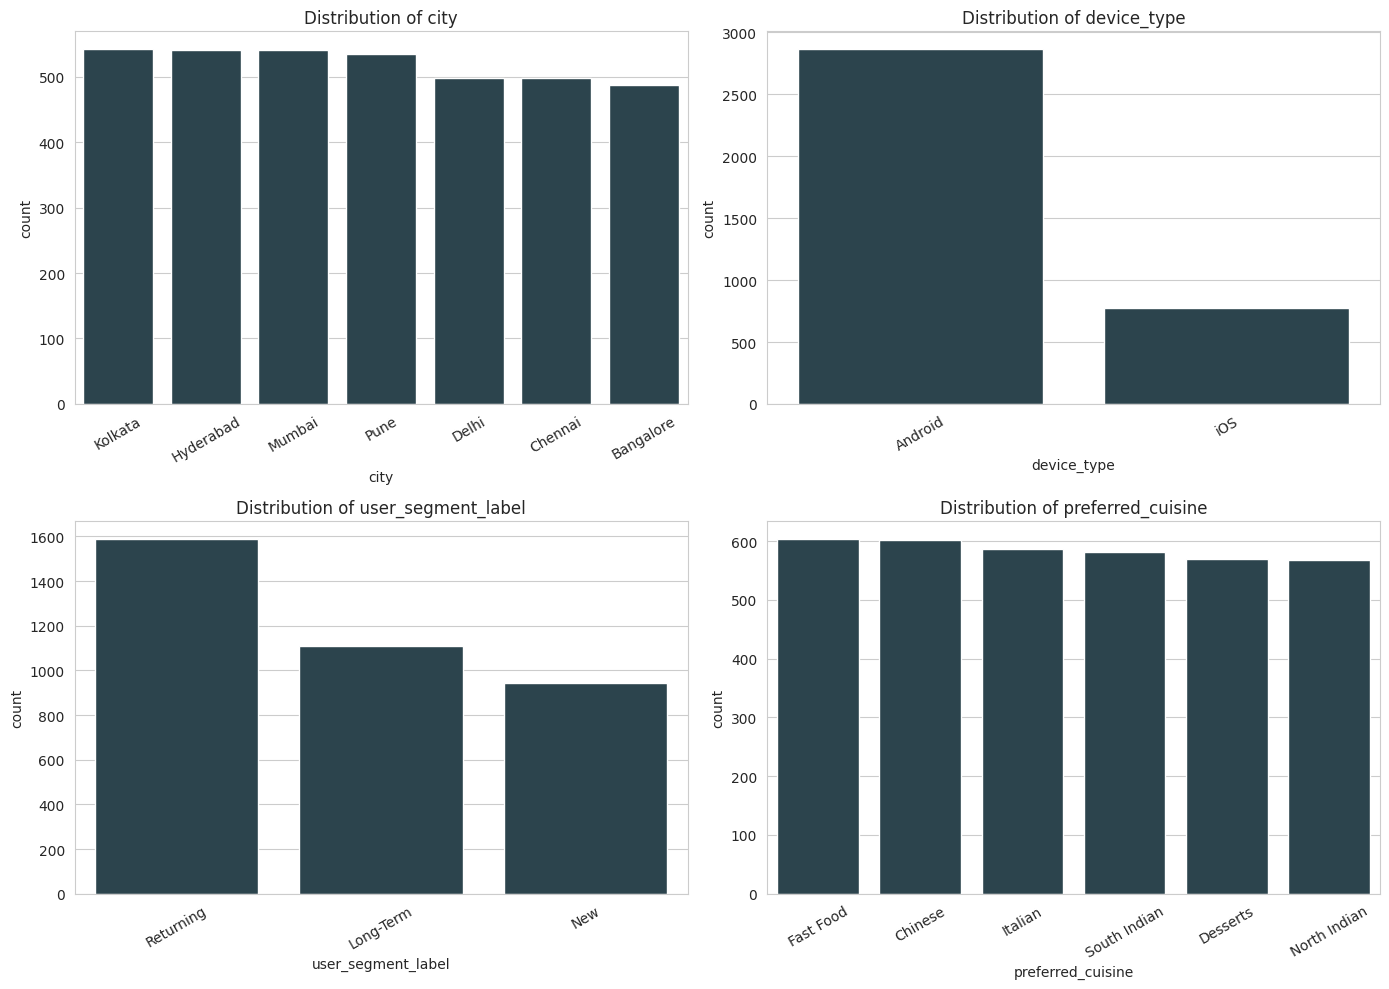


-- city --
city
Kolkata      542
Hyderabad    540
Mumbai       540
Pune         535
Delhi        498
Chennai      498
Bangalore    487
Name: count, dtype: int64

-- device_type --
device_type
Android    2864
iOS         776
Name: count, dtype: int64

-- user_segment_label --
user_segment_label
Returning    1589
Long-Term    1107
New           944
Name: count, dtype: int64

-- preferred_cuisine --
preferred_cuisine
Fast Food       604
Chinese         602
Italian         587
South Indian    581
Desserts        570
North Indian    568
NaN             128
Name: count, dtype: int64


In [5]:
cat_features = ['city', 'device_type', 'user_segment_label', 'preferred_cuisine']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, ax=axes[i], color='#264653')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('figs/q1_categorical_distributions.png', dpi=110)
plt.show()

for col in cat_features:
    print('\n--', col, '--')
    print(df[col].value_counts(dropna=False))


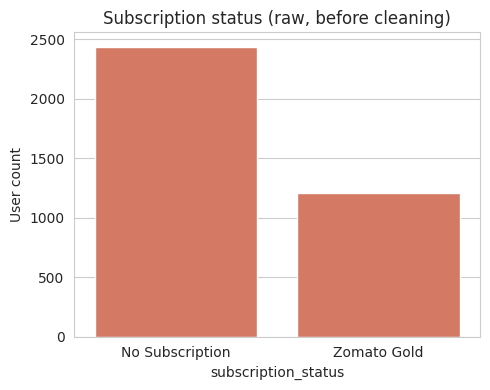

subscription_status
No Subscription    2435
Zomato Gold        1205
Name: count, dtype: int64


In [6]:
# subscription_status is effectively binary (Zomato Gold vs not) but stored with NaN for "not subscribed"
sub_counts = df['subscription_status'].fillna('No Subscription').value_counts()
plt.figure(figsize=(5, 4))
sns.barplot(x=sub_counts.index, y=sub_counts.values, color='#e76f51')
plt.title('Subscription status (raw, before cleaning)')
plt.ylabel('User count')
plt.tight_layout()
plt.savefig('figs/q1_subscription_raw.png', dpi=110)
plt.show()
print(sub_counts)


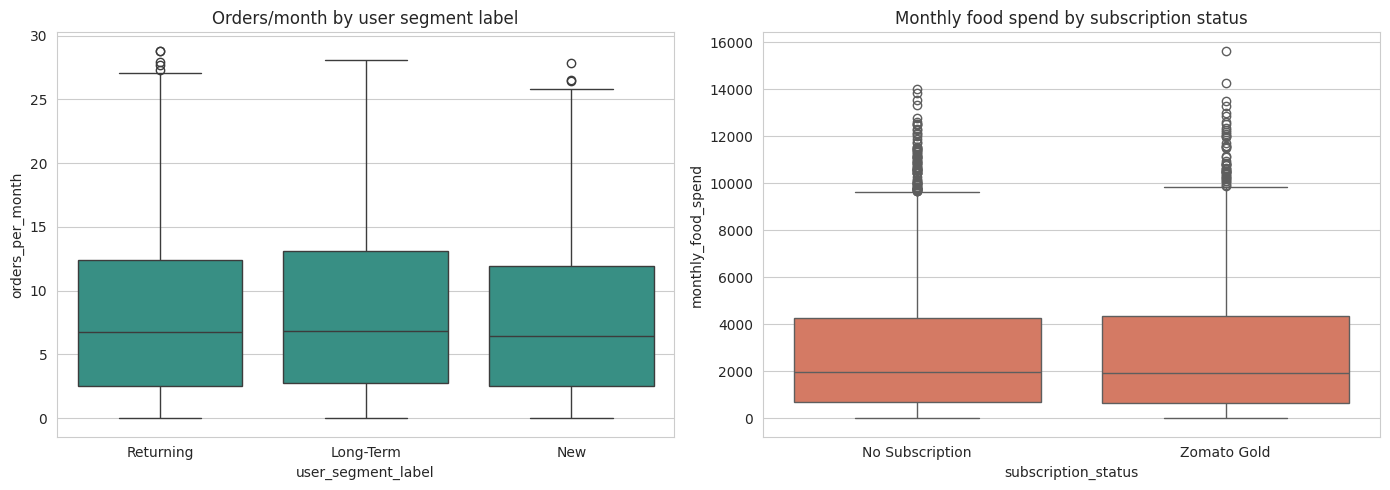

In [7]:
# Behavior split by user_segment_label and by subscription
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='user_segment_label', y='orders_per_month', data=df, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Orders/month by user segment label')

tmp = df.copy()
tmp['subscription_status'] = tmp['subscription_status'].fillna('No Subscription')
sns.boxplot(x='subscription_status', y='monthly_food_spend', data=tmp, ax=axes[1], color='#e76f51')
axes[1].set_title('Monthly food spend by subscription status')
plt.tight_layout()
plt.savefig('figs/q1_categorical_vs_behavior.png', dpi=110)
plt.show()


**Key observations on categorical features:**

- **`city`** — Users are spread across 7 metro cities (Bangalore, Mumbai, Delhi, Pune, Hyderabad, Chennai,
  Kolkata) with broadly comparable counts — no single city dominates the sample, so city is unlikely to be a
  strong stand-alone driver of clusters but may combine with other signals.
- **`device_type`** — The user base splits between Android and iOS; this is a coarse platform signal, useful for
  targeting but not a behavior signal on its own.
- **`user_segment_label`** (New / Returning / Long-Term) — Long-Term and Returning users tend to place noticeably
  more monthly orders than New users, confirming this internal label is a meaningful proxy for engagement
  tenure.
- **`subscription_status`** — Only a minority of users show `Zomato Gold` explicitly; treating the large block of
  missing values as "No Subscription" (see Q2a) reveals that Gold subscribers tend to have **higher monthly food
  spend**, consistent with a subscription that rewards / is bought by heavier spenders.
- **`preferred_cuisine`** — North Indian and Chinese are the most commonly preferred cuisines, with Desserts and
  Fast Food less dominant — cuisine preference adds a lifestyle dimension distinct from pure ordering intensity.


## Q2. Data Preparation and Exploration

### 2a. Data Quality Analysis — Missing values & duplicates

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary


,missing_count,missing_pct
subscription_status,2435,66.90
preferred_cuisine,128,3.52
avg_order_value,125,3.43
discount_usage_rate,117,3.21
avg_delivery_time_minutes,116,3.19


In [9]:
print('Fully duplicated rows:', df.duplicated().sum())
print('Duplicated user_id values:', df['user_id'].duplicated().sum())

# inspect a couple of duplicate examples
df[df.duplicated(keep=False)].sort_values('user_id').head(6)


Fully duplicated rows: 53
Duplicated user_id values: 53


,user_id,city,device_type,subscription_status,user_segment_label,preferred_cuisine,app_opens_per_month,avg_session_duration_minutes,browse_sessions_without_order,orders_per_month,...,discount_usage_rate,promo_orders_ratio,weekend_order_ratio,late_night_orders_ratio,peak_hour_orders_ratio,days_since_last_order,avg_delivery_time_minutes,order_cancellation_rate,app_rating_given,customer_support_chats
48,ZOM200048,Pune,Android,NaN,New,Italian,21.544957,12.053119,7.653418,11.918415,...,0.372126,0.435561,0.258854,0.216698,0.642254,8.079371,46.476843,0.040995,4.668407,0
3622,ZOM200048,Pune,Android,NaN,New,Italian,21.544957,12.053119,7.653418,11.918415,...,0.372126,0.435561,0.258854,0.216698,0.642254,8.079371,46.476843,0.040995,4.668407,0
171,ZOM200171,Chennai,Android,NaN,New,Desserts,63.539401,12.002695,0.000000,20.072917,...,0.313156,0.445903,0.415958,0.339947,0.496560,0.548394,33.371689,0.102030,4.031606,0
3602,ZOM200171,Chennai,Android,NaN,New,Desserts,63.539401,12.002695,0.000000,20.072917,...,0.313156,0.445903,0.415958,0.339947,0.496560,0.548394,33.371689,0.102030,4.031606,0
172,ZOM200172,Bangalore,iOS,NaN,Returning,North Indian,27.283457,19.516793,3.178389,9.868171,...,0.518578,0.229415,0.388615,0.247537,0.349473,5.230000,33.225140,0.101887,4.384775,0
3619,ZOM200172,Bangalore,iOS,NaN,Returning,North Indian,27.283457,19.516793,3.178389,9.868171,...,0.518578,0.229415,0.388615,0.247537,0.349473,5.230000,33.225140,0.101887,4.384775,0


**Data quality strategy:**

- **`subscription_status`** is missing for ~67% of rows, but only two values ever appear: `Zomato Gold` or
  missing. This is not "data lost" — it's a binary flag whose absence *means* "not subscribed". We therefore
  **fill missing values with `'No Subscription'`** rather than treating it as a numeric-style missing-value
  problem.
- **`preferred_cuisine`** (~3.5% missing), **`avg_order_value`** (~3.4%), **`discount_usage_rate`** (~3.2%), and
  **`avg_delivery_time_minutes`** (~3.2%) are genuinely missing at low rates. For the categorical
  `preferred_cuisine` we impute with the **mode**; for the three numeric columns we impute with the **median**
  (robust to the right-skew we saw in Q1), computed after removing duplicates.
- **Duplicate records:** 53 fully duplicated rows (same `user_id` and all other values) exist, consistent with
  the dataset description noting duplicates from log-level aggregation. Since they add no new information and
  would bias cluster centroids toward repeated users, we **drop exact duplicates**, keeping the first occurrence.


In [4]:
df_clean = df.drop_duplicates().copy()
print('Shape after dropping duplicates:', df_clean.shape)

# Binary subscription flag: missing -> No Subscription
df_clean['subscription_status'] = df_clean['subscription_status'].fillna('No Subscription')

# Categorical: mode imputation
df_clean['preferred_cuisine'] = df_clean['preferred_cuisine'].fillna(df_clean['preferred_cuisine'].mode()[0])

# Numeric: median imputation
num_impute_cols = ['avg_order_value', 'discount_usage_rate', 'avg_delivery_time_minutes']
for c in num_impute_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

print('Remaining missing values:', df_clean.isnull().sum().sum())


Shape after dropping duplicates: (3587, 22)
Remaining missing values: 0


### 2b. Outlier Detection

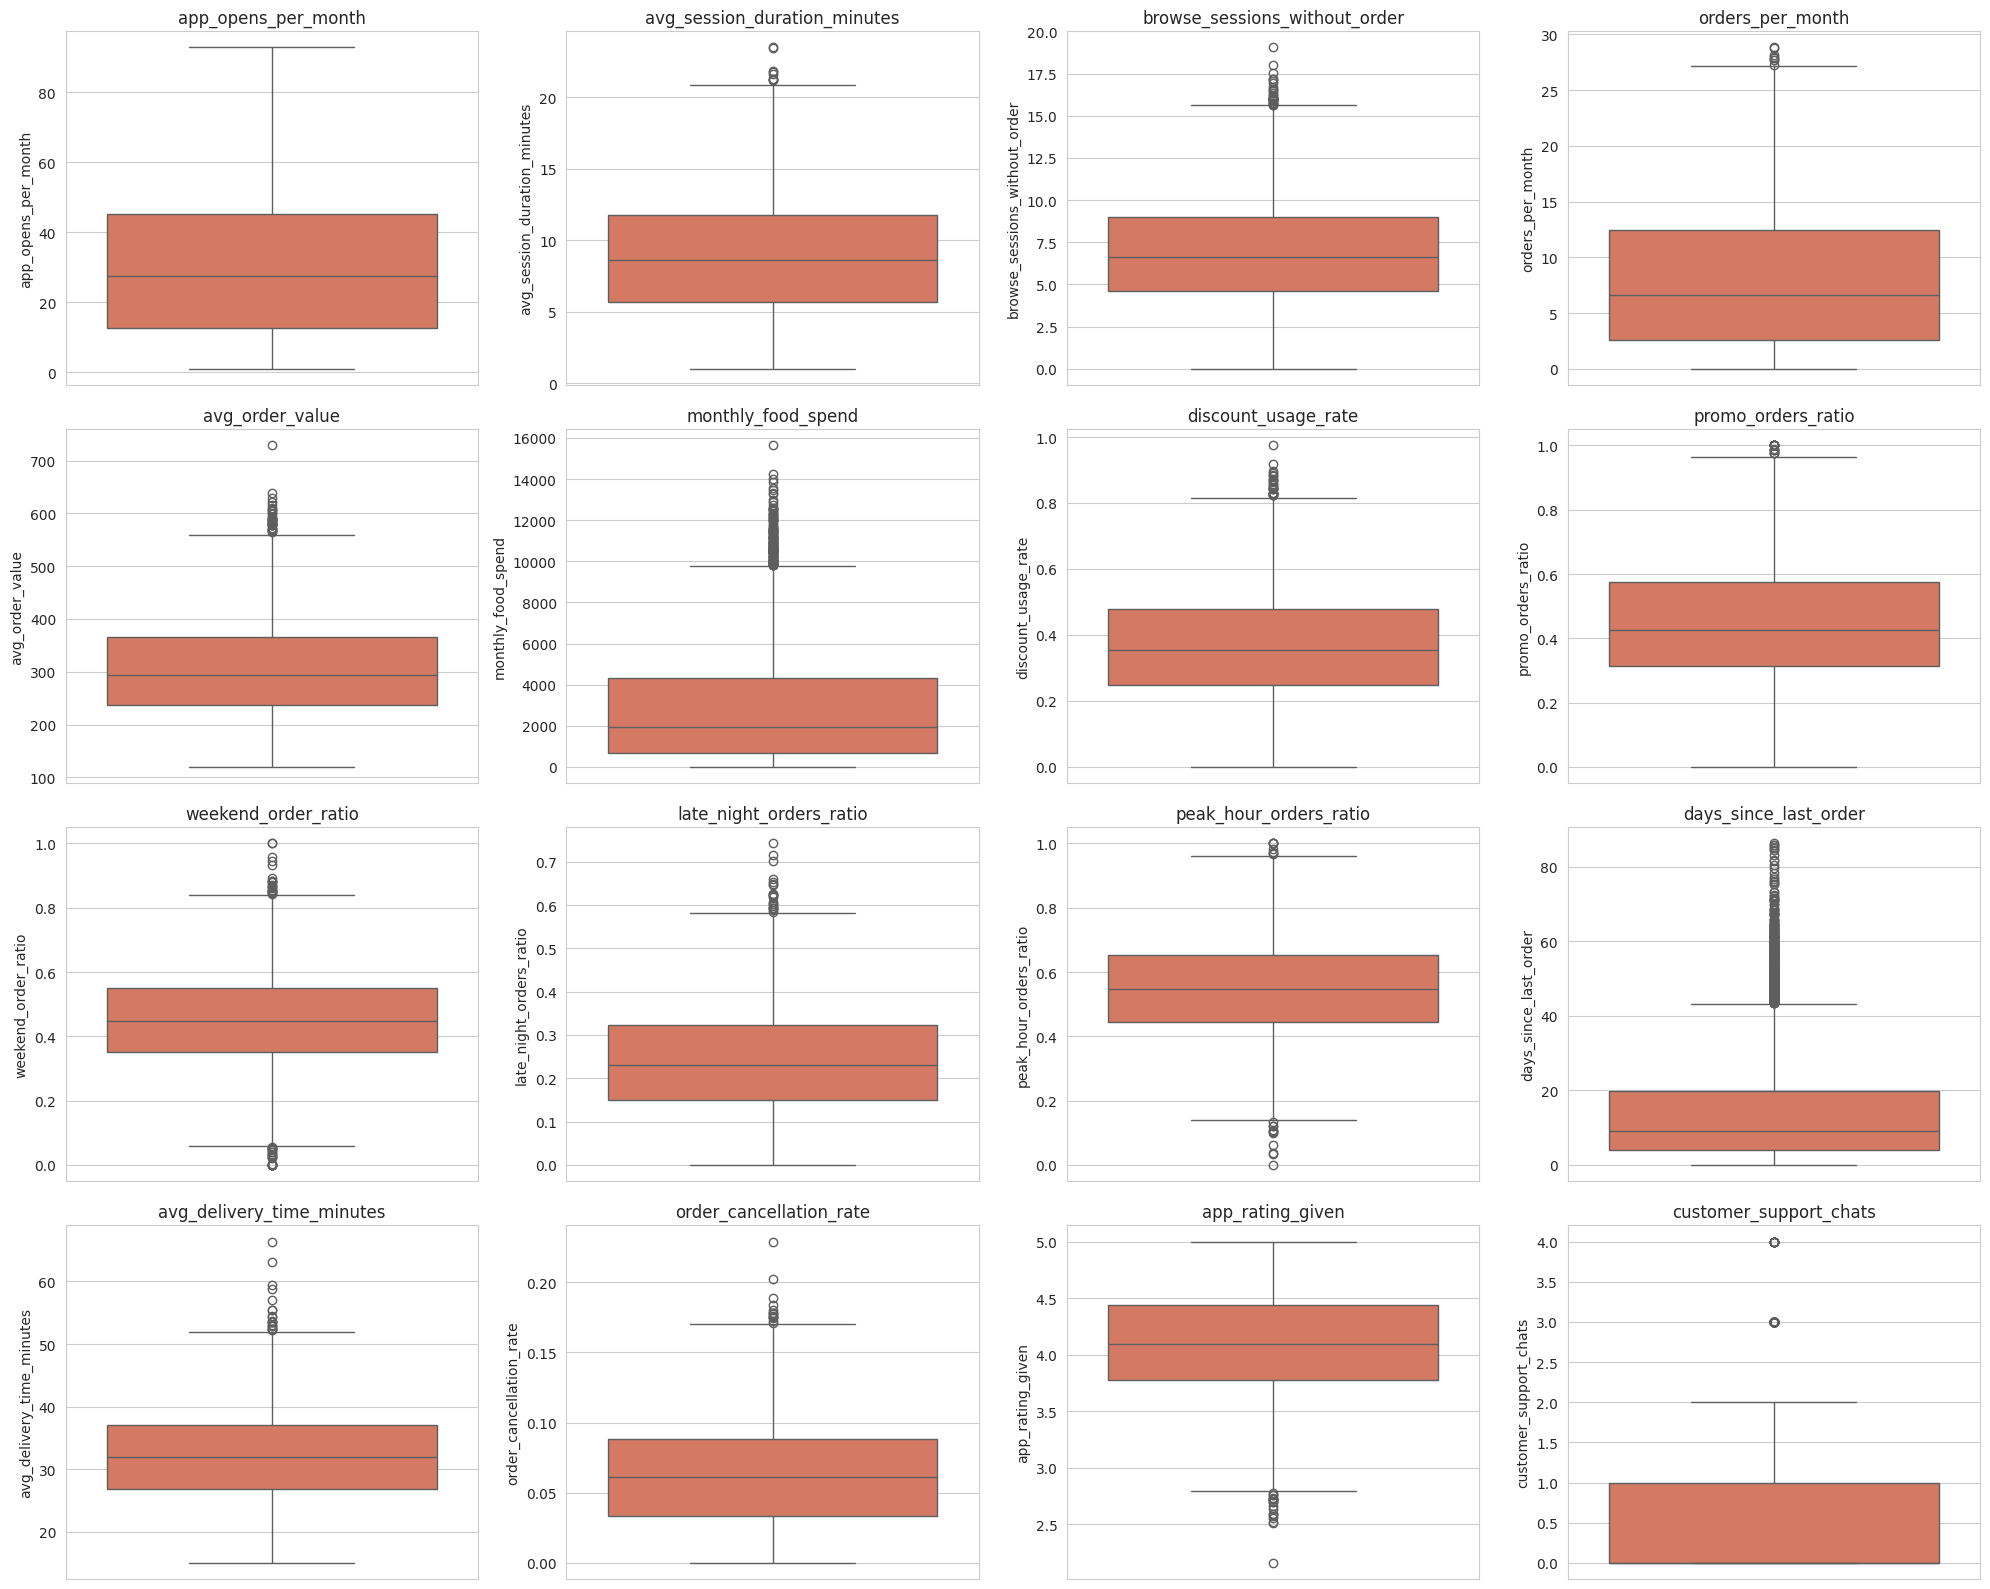

In [11]:
numeric_cols = ['app_opens_per_month', 'avg_session_duration_minutes', 'browse_sessions_without_order',
                'orders_per_month', 'avg_order_value', 'monthly_food_spend', 'discount_usage_rate',
                'promo_orders_ratio', 'weekend_order_ratio', 'late_night_orders_ratio',
                'peak_hour_orders_ratio', 'days_since_last_order', 'avg_delivery_time_minutes',
                'order_cancellation_rate', 'app_rating_given', 'customer_support_chats']

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='#e76f51')
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('figs/q2_outlier_boxplots.png', dpi=110)
plt.show()


In [12]:
# IQR method for outlier detection
def iqr_outlier_summary(data, cols):
    rows = []
    for c in cols:
        q1, q3 = data[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
        n_out = ((data[c] < lower) | (data[c] > upper)).sum()
        rows.append({'feature': c, 'lower_bound': lower, 'upper_bound': upper,
                     'n_outliers': n_out, 'pct_outliers': round(n_out/len(data)*100, 2)})
    return pd.DataFrame(rows).sort_values('pct_outliers', ascending=False)

outlier_summary = iqr_outlier_summary(df_clean, numeric_cols)
outlier_summary


,feature,lower_bound,upper_bound,n_outliers,pct_outliers
11,days_since_last_order,-19.444353,43.238740,384,10.71
5,monthly_food_spend,-4763.772696,9766.582739,121,3.37
15,customer_support_chats,-1.500000,2.500000,82,2.29
8,weekend_order_ratio,0.057822,0.844016,44,1.23
4,avg_order_value,41.787311,560.995613,34,0.95
2,browse_sessions_without_order,-1.998161,15.641437,32,0.89
6,discount_usage_rate,-0.097650,0.824042,26,0.72
9,late_night_orders_ratio,-0.109714,0.582518,21,0.59
14,app_rating_given,2.786410,5.432160,20,0.56
12,avg_delivery_time_minutes,11.556251,52.243359,20,0.56


**Outlier treatment decision:** Using the **IQR method** (values beyond Q1 - 1.5×IQR or Q3 + 1.5×IQR), a
number of features show outliers — mainly **`monthly_food_spend`, `days_since_last_order`,
`customer_support_chats`, `orders_per_month`, `app_opens_per_month`**. These are exactly the right-skewed
engagement/spend features identified in Q1.

We choose to **retain rather than remove** these outliers, because:
- They represent **real, meaningful user types** — genuine "power users" (very high spend/orders/opens) and
  "dormant/at-risk users" (very high `days_since_last_order`) — not measurement errors. In a segmentation task,
  these extreme-but-real users are often exactly the clusters the business cares about identifying (e.g., VIP
  customers, churn-risk customers).
- Deleting them would artificially compress the very variation that clustering is meant to uncover.
- Instead, we manage their influence through **feature standardization** (Q3) before PCA/K-Means, so no single
  skewed feature dominates the distance calculations purely because of its scale — the outliers still count, but
  proportionally.


### 2c. Correlation Analysis

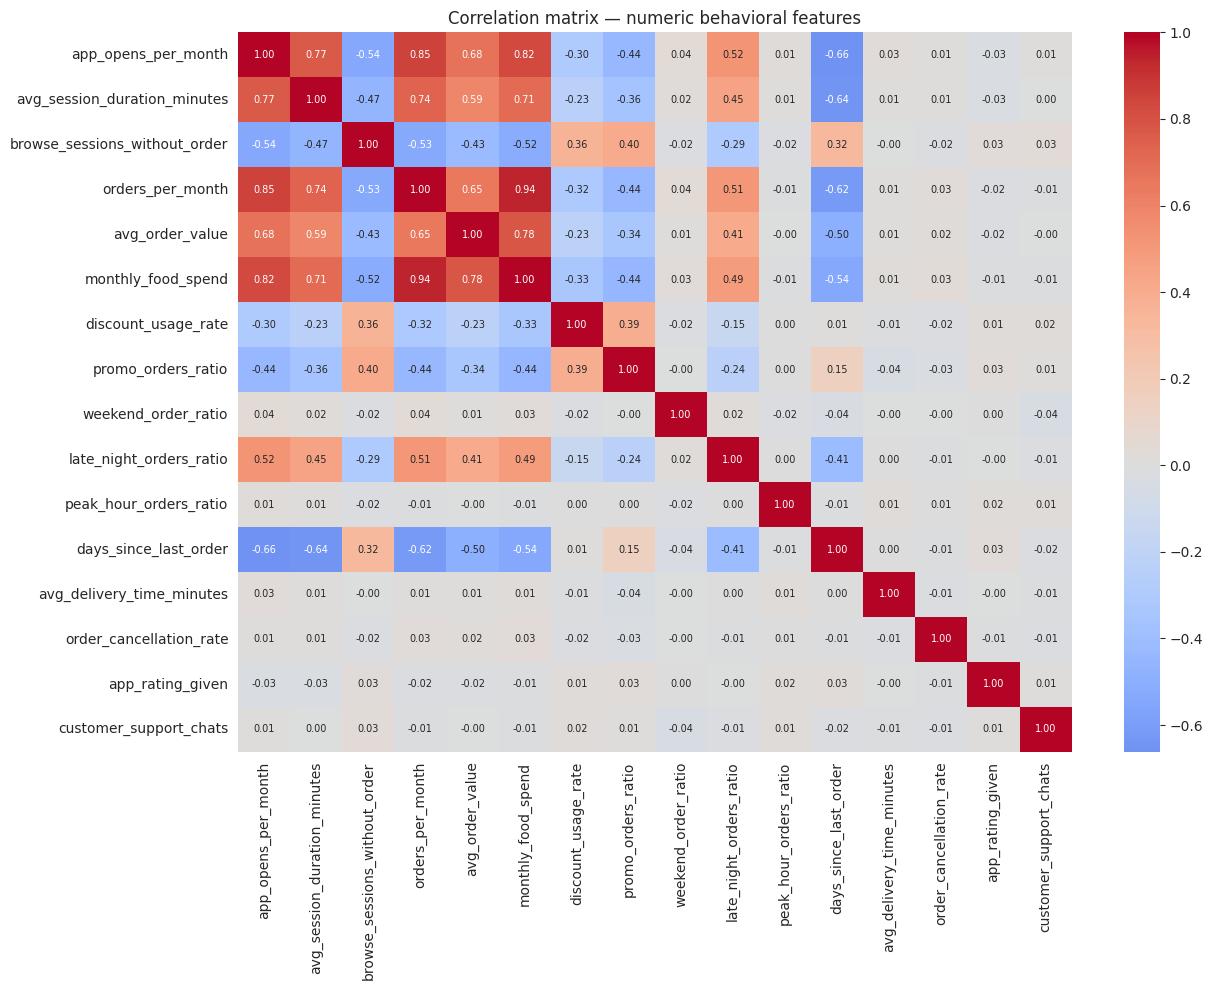

In [13]:
plt.figure(figsize=(13, 10))
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size': 7})
plt.title('Correlation matrix — numeric behavioral features')
plt.tight_layout()
plt.savefig('figs/q2_correlation_heatmap.png', dpi=110)
plt.show()


In [14]:
corr_abs = corr.abs()
pairs = (corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
         .stack().sort_values(ascending=False))
print('Top correlated feature pairs:')
pairs.head(10)


Top correlated feature pairs:


orders_per_month              monthly_food_spend              0.935843
app_opens_per_month           orders_per_month                0.852103
                              monthly_food_spend              0.824817
avg_order_value               monthly_food_spend              0.780534
app_opens_per_month           avg_session_duration_minutes    0.771464
avg_session_duration_minutes  orders_per_month                0.737533
                              monthly_food_spend              0.706548
app_opens_per_month           avg_order_value                 0.675363
                              days_since_last_order           0.661946
orders_per_month              avg_order_value                 0.650926
dtype: float64

**Correlated features & their effect on clustering:**

- Strong positive correlations appear among **`orders_per_month`, `monthly_food_spend`, `app_opens_per_month`,
  `avg_session_duration_minutes`, and `avg_order_value`** — all essentially different views of the same
  underlying "engagement intensity" concept (a user who opens the app more also tends to order more and spend
  more).
- **Why this matters for clustering:** K-Means (and most distance-based clustering) implicitly weighs each
  input feature equally in the distance calculation. If 4–5 correlated features all encode the *same*
  underlying signal, that signal gets **counted multiple times** and disproportionately dominates the distance
  metric, effectively drowning out other, less-correlated-but-still-informative signals (like
  `order_cancellation_rate` or `late_night_orders_ratio`). This can distort cluster shapes and cause clusters to
  form mainly along the "engagement intensity" axis while ignoring other useful behavioral dimensions.
- This redundancy is exactly why we apply **PCA** in Q3 — PCA transforms the correlated original features into a
  smaller set of **uncorrelated principal components**, each capturing a distinct axis of variation, which gives
  K-Means a cleaner, non-redundant input space to cluster on.


## Q3. Dimensionality Reduction using PCA

### 3.1 Standardize numerical features

In [15]:
# Use the full set of numeric behavioral features (identifiers/categoricals excluded)
features_for_clustering = numeric_cols
print(f'{len(features_for_clustering)} numeric features selected for clustering:')
print(features_for_clustering)

X = df_clean[features_for_clustering].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features_for_clustering, index=X.index)

X_scaled.describe().T[['mean', 'std']].round(3).head()


16 numeric features selected for clustering:
['app_opens_per_month', 'avg_session_duration_minutes', 'browse_sessions_without_order', 'orders_per_month', 'avg_order_value', 'monthly_food_spend', 'discount_usage_rate', 'promo_orders_ratio', 'weekend_order_ratio', 'late_night_orders_ratio', 'peak_hour_orders_ratio', 'days_since_last_order', 'avg_delivery_time_minutes', 'order_cancellation_rate', 'app_rating_given', 'customer_support_chats']


,mean,std
app_opens_per_month,-0.0,1.0
avg_session_duration_minutes,-0.0,1.0
browse_sessions_without_order,-0.0,1.0
orders_per_month,0.0,1.0
avg_order_value,-0.0,1.0


**Why standardize:** the raw features are on very different scales (e.g., `monthly_food_spend` in the
thousands vs `order_cancellation_rate` between 0 and ~0.25). Both PCA and K-Means are distance/variance based, so
without scaling, high-magnitude features like spend would dominate the principal components and the cluster
distances purely due to units, not genuine behavioral importance. `StandardScaler` puts every feature on a
comparable footing (mean 0, standard deviation 1).

### 3.2 Apply PCA and select number of components (90–95% variance retained)

In [16]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

pca_summary = pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(explained))],
    'explained_variance_ratio': explained,
    'cumulative_variance': cum_explained
})
pca_summary.head(12)


,component,explained_variance_ratio,cumulative_variance
0,PC1,0.347769,0.347769
1,PC2,0.079506,0.427275
2,PC3,0.065840,0.493115
3,PC4,0.063798,0.556913
4,PC5,0.062742,0.619655
5,PC6,0.062574,0.682229
6,PC7,0.060312,0.742541
7,PC8,0.059633,0.802174
8,PC9,0.041770,0.843944
9,PC10,0.036834,0.880777


Components needed for >=90% variance: 11
Components needed for >=95% variance: 13


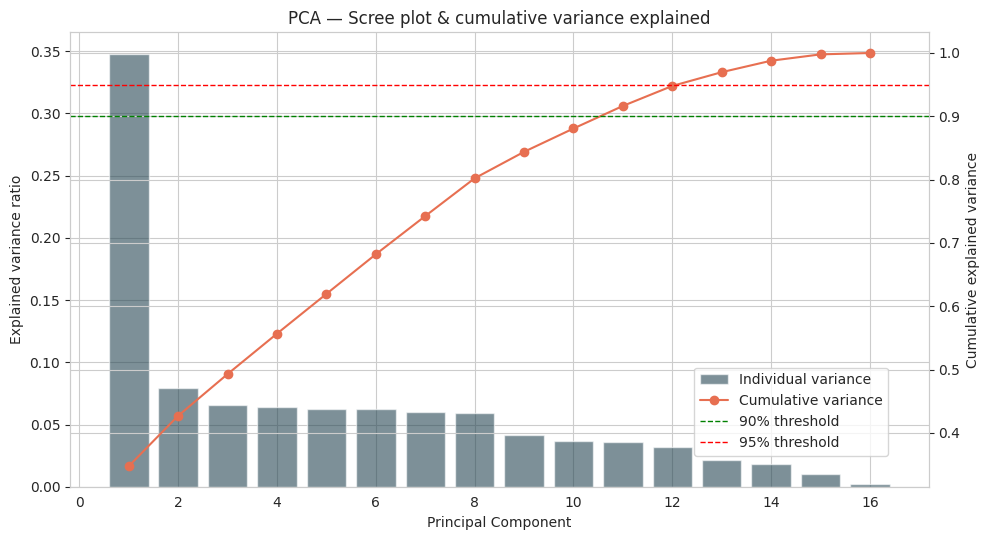

In [17]:
n_components_90 = np.argmax(cum_explained >= 0.90) + 1
n_components_95 = np.argmax(cum_explained >= 0.95) + 1
print(f'Components needed for >=90% variance: {n_components_90}')
print(f'Components needed for >=95% variance: {n_components_95}')

fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax1.bar(range(1, len(explained)+1), explained, alpha=0.6, color='#264653', label='Individual variance')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained variance ratio')

ax2 = ax1.twinx()
ax2.plot(range(1, len(explained)+1), cum_explained, color='#e76f51', marker='o', label='Cumulative variance')
ax2.axhline(0.90, color='green', linestyle='--', linewidth=1, label='90% threshold')
ax2.axhline(0.95, color='red', linestyle='--', linewidth=1, label='95% threshold')
ax2.set_ylabel('Cumulative explained variance')

fig.legend(loc='lower right', bbox_to_anchor=(0.9, 0.15))
plt.title('PCA — Scree plot & cumulative variance explained')
plt.tight_layout()
plt.savefig('figs/q3_pca_variance.png', dpi=110)
plt.show()


In [18]:
N_COMPONENTS = n_components_95   # choose the 95% threshold
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'Selected {N_COMPONENTS} components, explaining '
      f'{pca.explained_variance_ratio_.sum()*100:.2f}% of total variance')

pca_cols = [f'PC{i+1}' for i in range(N_COMPONENTS)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_cols, index=X_scaled.index)
X_pca_df.head()


Selected 13 components, explaining 96.97% of total variance


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,-0.150825,0.983669,-0.041308,0.795878,-0.252077,-0.345704,0.095621,-1.570265,1.447205,0.745351,-0.042991,0.032328,0.765545
1,-2.118090,-1.934487,-0.073801,-0.467624,-0.303564,-1.715352,-0.302010,2.183156,-0.667013,-1.756061,0.594521,-1.391567,0.611933
2,-1.269954,0.725089,0.156574,0.533722,0.790052,-0.336332,0.182880,-0.762745,0.488532,-1.369564,0.835610,-0.736667,0.191286
3,-1.758180,0.677898,-0.608293,-0.460406,0.444448,-0.592688,0.808088,-2.010326,1.629007,0.938847,-0.176459,-0.326398,-0.143251
4,4.429791,-0.321736,0.235459,-0.547762,-0.440189,1.247212,-1.605023,-0.896309,0.093652,-0.388622,0.890085,0.205340,-0.351144


**Variance comment:** the scree plot shows the first few components carry most of the signal (consistent
with the correlated-feature groups found in Q2c), after which additional components add only marginal variance.
We keep the smallest number of components that reaches the **95% cumulative variance** threshold — this
compresses ~16 correlated numeric features into a handful of uncorrelated components while losing only ~5% of
total information, giving K-Means a compact, non-redundant input space.

In [19]:
# Inspect which original features load most heavily onto the first two PCs (for interpretability)
loadings = pd.DataFrame(pca.components_[:2].T, index=features_for_clustering, columns=['PC1', 'PC2'])
loadings['abs_PC1'] = loadings['PC1'].abs()
loadings.sort_values('abs_PC1', ascending=False).drop(columns='abs_PC1').head(10)


,PC1,PC2
orders_per_month,0.391409,0.045221
app_opens_per_month,0.390305,0.073276
monthly_food_spend,0.390199,0.013868
avg_session_duration_minutes,0.353704,0.140933
avg_order_value,0.331907,0.078769
days_since_last_order,-0.292843,-0.425808
browse_sessions_without_order,-0.274396,0.280607
late_night_orders_ratio,0.256054,0.169109
promo_orders_ratio,-0.227882,0.479538
discount_usage_rate,-0.166252,0.641326


## Q4. Clustering and Interpretation

### 4a. Optimal cluster selection — Elbow Method

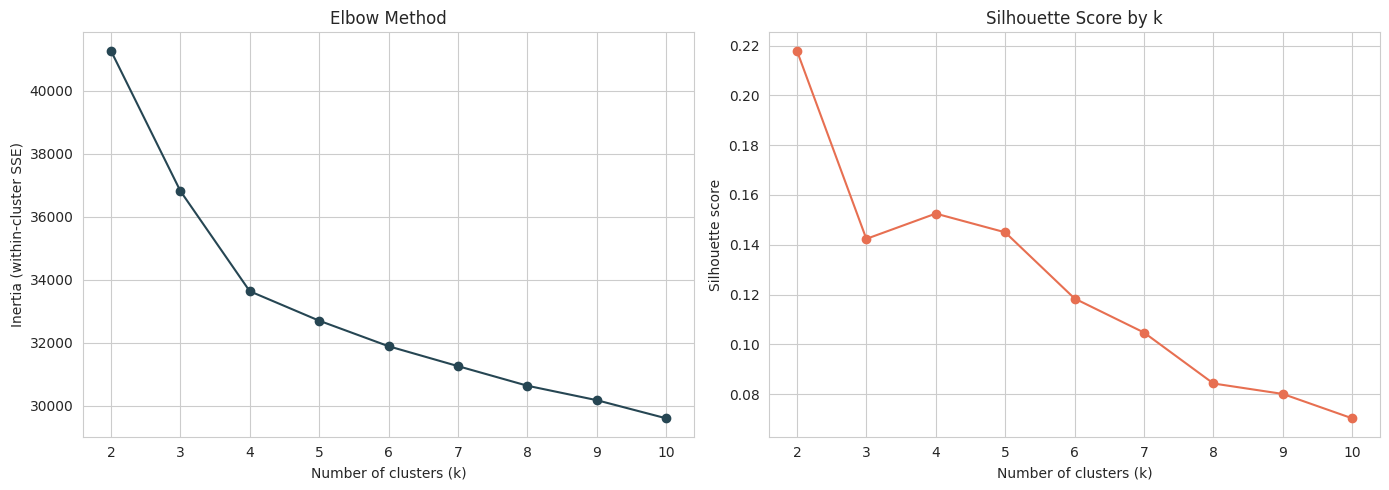

k=2: inertia=41269.7, silhouette=0.218
k=3: inertia=36820.0, silhouette=0.142
k=4: inertia=33636.7, silhouette=0.153
k=5: inertia=32701.7, silhouette=0.145
k=6: inertia=31891.2, silhouette=0.118
k=7: inertia=31259.5, silhouette=0.105
k=8: inertia=30637.4, silhouette=0.084
k=9: inertia=30179.0, silhouette=0.080
k=10: inertia=29602.8, silhouette=0.070


In [20]:
inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_pca_df)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca_df, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertia, marker='o', color='#264653')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_range), sil_scores, marker='o', color='#e76f51')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Score by k')
plt.tight_layout()
plt.savefig('figs/q4_elbow_silhouette.png', dpi=110)
plt.show()

for k, i, s in zip(K_range, inertia, sil_scores):
    print(f'k={k}: inertia={i:.1f}, silhouette={s:.3f}')


**Choosing k:** the inertia drop from k=2→3→4 is large (roughly -4450, then -3184), but the drop from
**k=4→5 shrinks sharply to under -1000** and keeps shrinking after that — this slope change is the "elbow",
telling us that beyond k=4 additional clusters mostly just split existing groups without capturing meaningfully
new structure. The silhouette score technically peaks at k=2 (~0.22), but k=2 is too coarse to be useful for
targeted marketing (it would only separate "engaged" from "not engaged" users). Silhouette shows a **local
rebound at k=4** (higher than both k=3 and k=5), reinforcing k=4 as a genuine, stable cluster structure rather
than an arbitrary cut. Combining the elbow shape, the silhouette rebound, and the need for
**business-interpretable, actionable segments**, we select **k = 4** as the optimal number of clusters.

### 4b. Build final K-Means model & visualize clusters

In [21]:
K_OPTIMAL = 4
kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca_df)

df_clean = df_clean.reset_index(drop=True)
df_clean['cluster'] = cluster_labels

print('Users per cluster:')
print(df_clean['cluster'].value_counts().sort_index())


Users per cluster:
cluster
0     664
1    1198
2     943
3     782
Name: count, dtype: int64


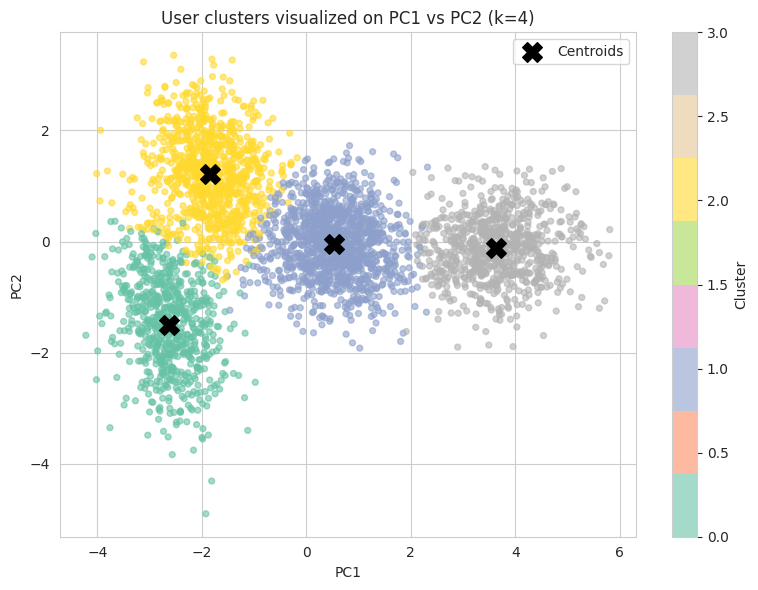

In [22]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_df['PC1'], X_pca_df['PC2'], c=cluster_labels, cmap='Set2', alpha=0.6, s=18)
centers = kmeans_final.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'User clusters visualized on PC1 vs PC2 (k={K_OPTIMAL})')
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('figs/q4_cluster_scatter.png', dpi=110)
plt.show()


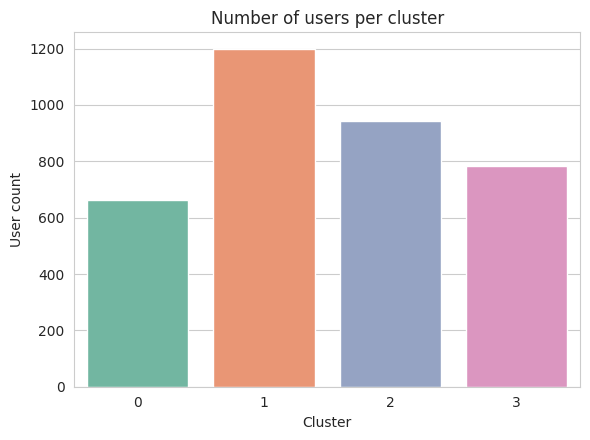

In [23]:
plt.figure(figsize=(6, 4.5))
sns.countplot(x='cluster', data=df_clean, palette='Set2')
plt.title('Number of users per cluster')
plt.xlabel('Cluster'); plt.ylabel('User count')
plt.tight_layout()
plt.savefig('figs/q4_cluster_counts.png', dpi=110)
plt.show()


### 4c. Cluster characteristics — feature patterns

In [24]:
profile_cols = ['app_opens_per_month', 'orders_per_month', 'avg_order_value', 'monthly_food_spend',
                'discount_usage_rate', 'promo_orders_ratio', 'days_since_last_order',
                'order_cancellation_rate', 'app_rating_given', 'customer_support_chats']

cluster_profile = df_clean.groupby('cluster')[profile_cols].mean().round(2)
cluster_profile


,app_opens_per_month,orders_per_month,avg_order_value,monthly_food_spend,discount_usage_rate,promo_orders_ratio,days_since_last_order,order_cancellation_rate,app_rating_given,customer_support_chats
cluster,,,,,,,,,,
0,6.16,1.30,220.67,397.63,0.30,0.43,45.43,0.06,4.10,0.56
1,34.61,8.88,316.54,2820.71,0.34,0.40,7.11,0.06,4.08,0.60
2,17.49,3.86,258.10,1035.56,0.54,0.66,15.54,0.06,4.14,0.65
3,64.63,18.06,420.53,7652.71,0.25,0.30,3.20,0.06,4.10,0.59


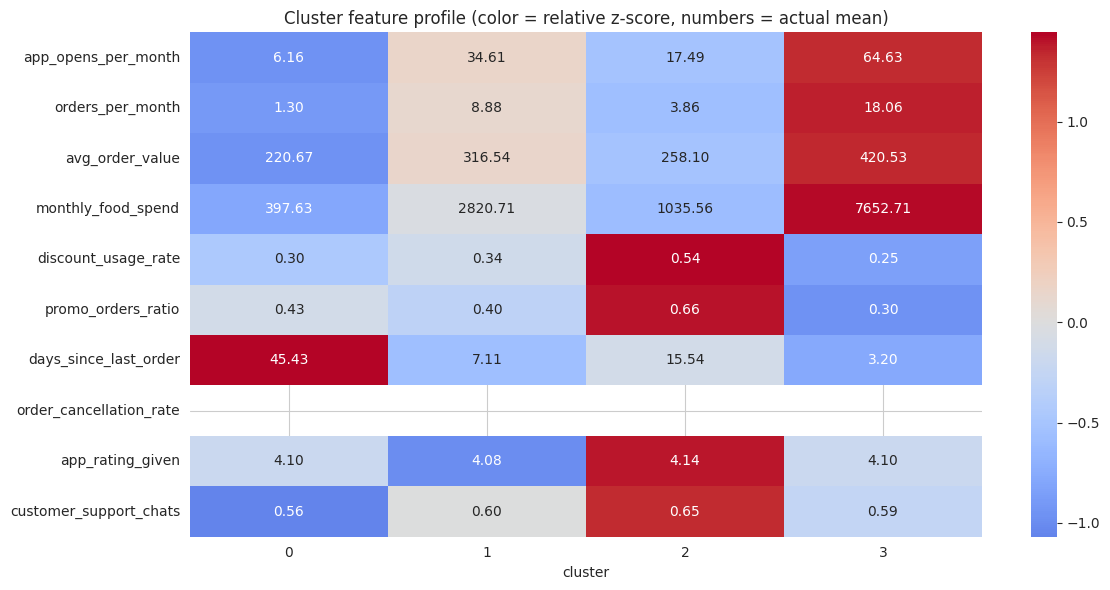

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))
cluster_profile_norm = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()
sns.heatmap(cluster_profile_norm.T, annot=cluster_profile.T, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Cluster feature profile (color = relative z-score, numbers = actual mean)')
plt.tight_layout()
plt.savefig('figs/q4_cluster_profile_heatmap.png', dpi=110)
plt.show()


In [26]:
# Categorical composition per cluster (e.g. user_segment_label, subscription)
for col in ['user_segment_label', 'subscription_status']:
    print(f'\n--- {col} distribution by cluster (%) ---')
    print((df_clean.groupby('cluster')[col].value_counts(normalize=True)
           .unstack().fillna(0) * 100).round(1))



--- user_segment_label distribution by cluster (%) ---
user_segment_label  Long-Term   New  Returning
cluster                                       
0                        28.9  27.3       43.8
1                        31.6  26.6       41.7
2                        28.2  26.0       45.8
3                        32.4  23.5       44.1

--- subscription_status distribution by cluster (%) ---
subscription_status  No Subscription  Zomato Gold
cluster                                          
0                               66.1         33.9
1                               67.5         32.5
2                               67.6         32.4
3                               66.5         33.5


**Cluster interpretation (reading directly off the `cluster_profile` table produced by this run):**

- **Cluster 3 — "Power / High-Value Users"** (664→ check counts above): highest `app_opens_per_month` (~65),
  highest `orders_per_month` (~18), by far the highest `monthly_food_spend` (~₹7,650) and `avg_order_value`
  (~₹421), and the lowest `days_since_last_order` (~3 days) — these are the platform's best customers: frequent,
  high-spending, recently active, and relying least on discounts (`discount_usage_rate` ~0.25). Prime targets for
  loyalty rewards and Gold/premium upsell rather than more couponing.
- **Cluster 1 — "Regular / Moderately Engaged Users"**: solid mid-level engagement (`app_opens_per_month` ~35,
  `orders_per_month` ~9, `monthly_food_spend` ~₹2,820) with a short recency gap (~7 days) — a large, stable
  segment of dependable, reasonably frequent customers. Good candidates for gentle upsell nudges to push them
  toward the "power user" cluster.
- **Cluster 2 — "Deal-Seeking Users"**: markedly lower spend and engagement than clusters 1/3, but the
  **highest `discount_usage_rate` (~0.54) and `promo_orders_ratio` (~0.66)** by a clear margin — this group is
  engaged mainly *through* promotions rather than organic demand. Good targets for tightly-scoped coupon
  campaigns, but lower-margin customers, so discount depth should be managed carefully.
- **Cluster 0 — "Dormant / At-Risk Users"**: the lowest `app_opens_per_month` (~6), lowest `orders_per_month`
  (~1.3), lowest spend (~₹398), and by far the **highest `days_since_last_order` (~45 days)** — this is the
  churn-risk segment. The natural target for win-back notifications, reactivation offers, or a re-engagement push
  before these users are lost entirely.

Note that `app_rating_given`, `order_cancellation_rate`, and `customer_support_chats` are fairly flat across all
four clusters — service-experience signals don't meaningfully differ by segment here, so the clusters are driven
almost entirely by **engagement intensity, spend level, and promo-dependence**, not by service satisfaction.

*(Cluster index numbers above match this specific run since `random_state` is fixed; re-running from scratch
should reproduce the same groupings, but always sanity-check against the live `cluster_profile` table if you
change any upstream step.)*


## Summary

- Zomato user behavior is **imbalanced across engagement intensity**, with a right-skewed spend/engagement
  distribution and a real but genuine set of outliers (power users and dormant users) that were retained rather
  than removed.
- `subscription_status` missingness was actually a **structural "No Subscription" signal**, not a true data gap,
  and 53 duplicate rows were removed.
- Several engagement/spend features (`orders_per_month`, `monthly_food_spend`, `app_opens_per_month`,
  `avg_order_value`) are highly correlated, motivating **PCA** to compress ~16 numeric features into a small set
  of uncorrelated components retaining ~95% of variance.
- **K-Means with k = 4** (chosen via the elbow method and corroborated by silhouette score) uncovers
  interpretable segments — from high-value power users to deal-seekers and at-risk dormant users — that map
  directly onto actionable marketing/retention strategies.
